In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

# Set a professional dark-styled background and font scale
sns.set_theme(style="darkgrid", font_scale=1.1)


In [2]:
df = pd.read_csv('ford.csv')
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (17966, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [4]:
print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isna().sum())


Statistical Summary:


,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000



Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


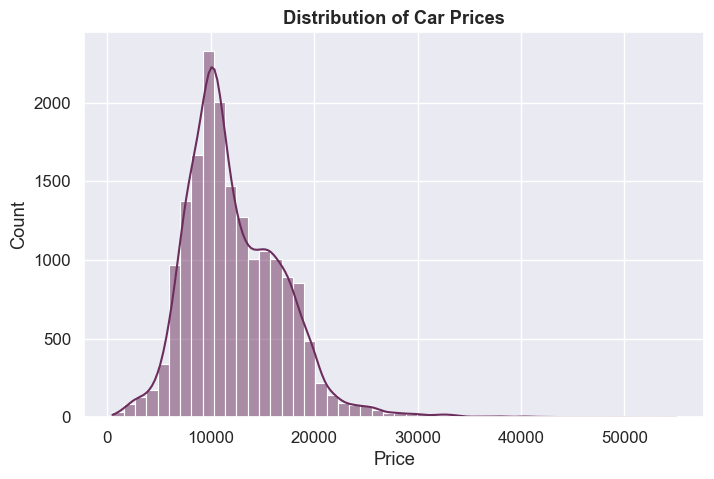

In [5]:
# 1. Distribution of Car Prices (Medium-dark purple with dark line)
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True, color='#6b2d5c')
plt.title('Distribution of Car Prices', fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


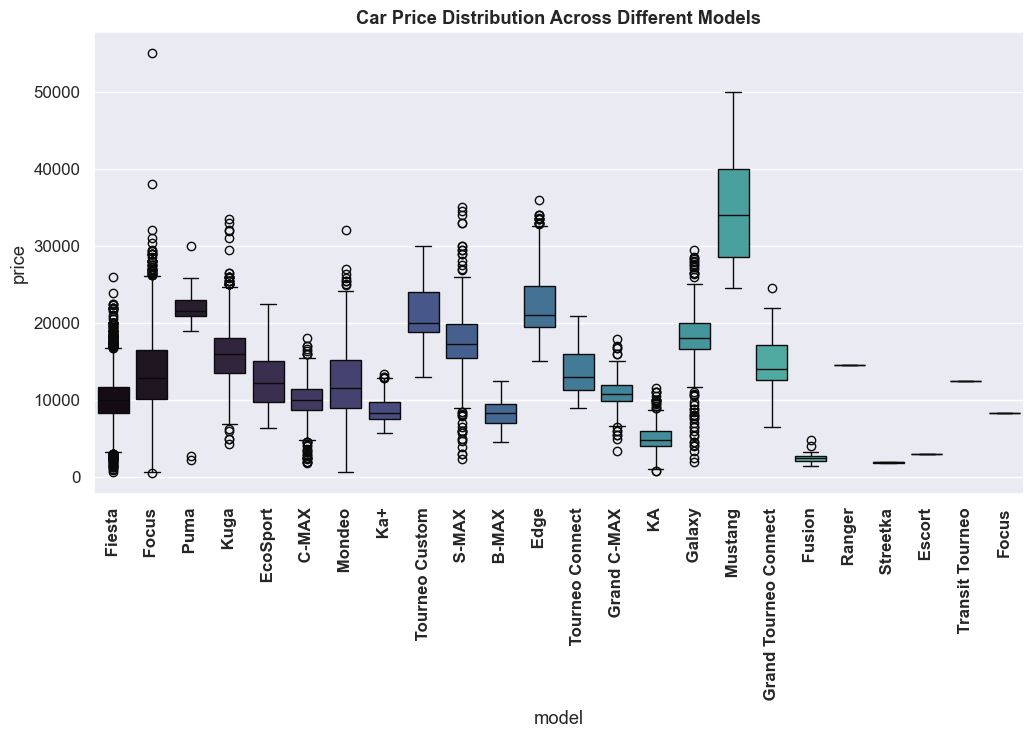

In [6]:
# 2. Car Price Distribution Across Models (Using a rich, medium-dark palette like 'mako' or 'cubehelix')
plt.figure(figsize=(12, 6))
sns.boxplot(x='model', y='price', data=df, palette='mako')
plt.xticks(rotation=90, fontweight='bold')
plt.title('Car Price Distribution Across Different Models', fontweight='bold')
plt.show()

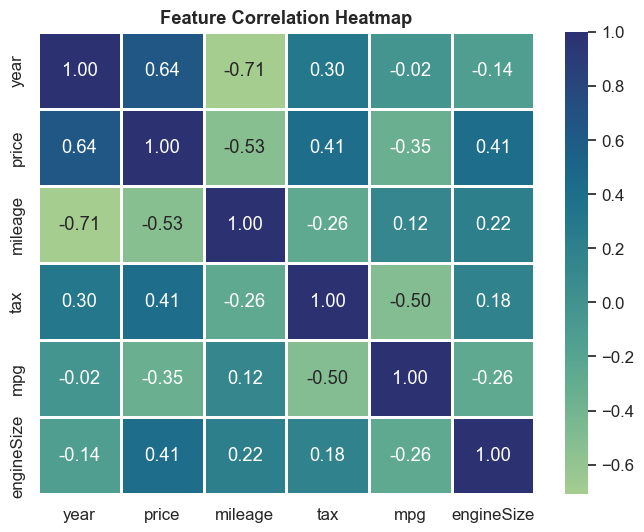

In [7]:
# 3. Feature Correlation Heatmap (Using 'crest' or 'vlag' for medium-dark contrast)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest', fmt='.2f', linewidths=0.8)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.show()

In [9]:
df = df[df['year'] <= 2026]

df['price_category'] = pd.qcut(df['price'], q=3, labels=[0, 1, 2])


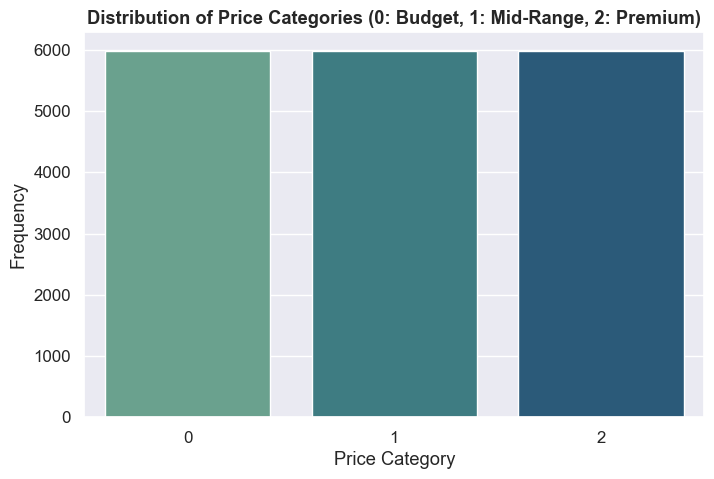

In [10]:
# 4. Distribution of Price Categories (Medium-dark color palette)
plt.figure(figsize=(8, 5))
sns.countplot(x=df['price_category'], palette='crest')
plt.title('Distribution of Price Categories (0: Budget, 1: Mid-Range, 2: Premium)', fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Frequency')
plt.show()

In [11]:
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']

In [12]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [13]:
print(f"Processed Feature Matrix Shape: {X.shape}")

Processed Feature Matrix Shape: (17965, 34)


In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [18]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"\n5-Fold Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")



5-Fold Cross-Validation Accuracy Scores: [0.83234783 0.84069565 0.83124565 0.855254   0.85316632]
Mean CV Accuracy: 0.8425


In [19]:
y_pred = model.predict(X_test_scaled)


In [21]:
acc_score = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [22]:
print(f"\n--- Model Evaluation Results ---")
print(f"Accuracy Score: {acc_score:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)


--- Model Evaluation Results ---
Accuracy Score: 0.8461
Weighted F1-Score: 0.8461

Confusion Matrix:
[[1048  162    1]
 [ 152  924  121]
 [   1  116 1068]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1211
           1       0.77      0.77      0.77      1197
           2       0.90      0.90      0.90      1185

    accuracy                           0.85      3593
   macro avg       0.85      0.85      0.85      3593
weighted avg       0.85      0.85      0.85      3593



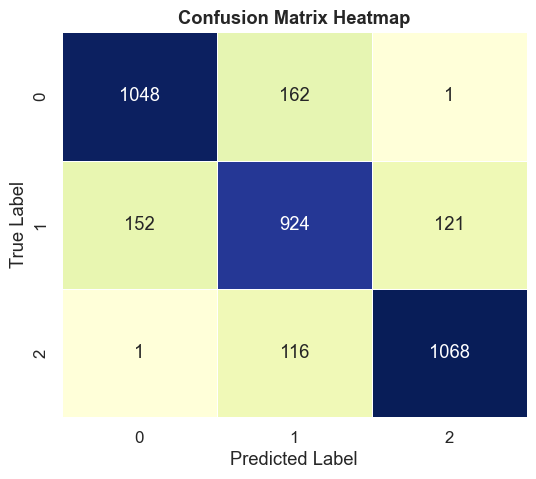

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False, linewidths=0.5)
plt.title('Confusion Matrix Heatmap', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


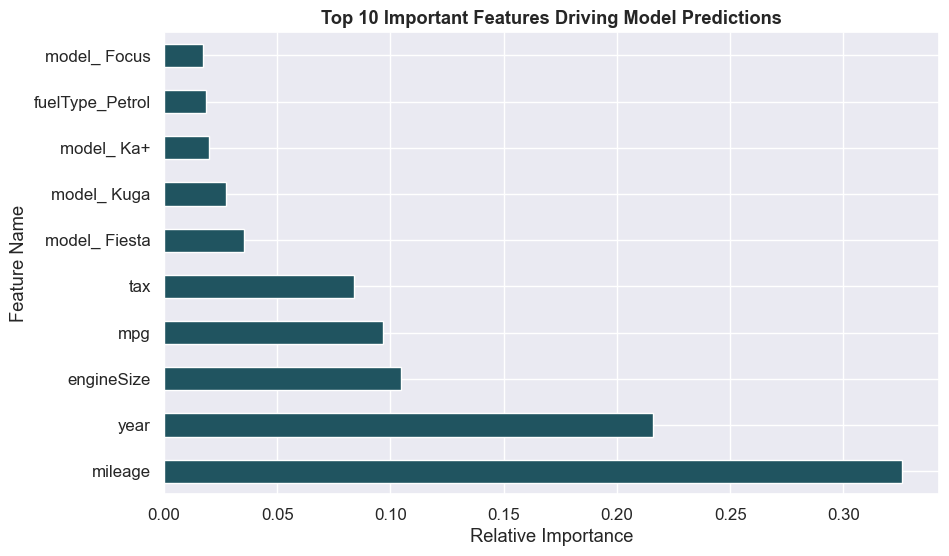

In [24]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='#205460')
plt.title('Top 10 Important Features Driving Model Predictions', fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.show()